# CVAE - Moreira2024

# Etapa 3

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DB_PATH = "../db/tfm_vocs.db"
PARQUET_PATH = "../db/data/processed/abundancias_moreira2024.csv"
DATASET_ORIGIN = "Moreira2024"

In [2]:
import pickle
import numpy as np
from pathlib import Path

MODELS_DIR = Path("../models")

def export_cvae(dataset_slug, encoder, decoder, iso_forest, autoencoder,
                 scores_loo, errores_loo_ae, scaler, compound_ids, meta=None):
    out = MODELS_DIR / dataset_slug
    out.mkdir(parents=True, exist_ok=True)
    encoder.save(out / "cvae_encoder.keras")
    decoder.save(out / "cvae_decoder.keras")
    autoencoder.save(out / "autoencoder.keras")

    with open(out / "isolation_forest.pkl", "wb") as f:
        pickle.dump(iso_forest, f)
    with open(out / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    with open(out / "compound_ids.pkl", "wb") as f:
        pickle.dump(list(compound_ids), f)

    np.save(out / "scores_loo.npy", scores_loo)
    np.save(out / "errores_loo_ae.npy", errores_loo_ae)

    if meta:
        with open(out / "cvae_meta.pkl", "wb") as f:
            pickle.dump(meta, f)

    print(f"Exportado CVAE+detectores: {dataset_slug} -> {out}")

In [3]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)

### Carga de datos

In [4]:
con = sqlite3.connect(DB_PATH)

muestras = pd.read_sql(
    f"SELECT * FROM muestras WHERE dataset_origin = '{DATASET_ORIGIN}'", con
)
compuestos = pd.read_sql(
    f"SELECT * FROM compuestos WHERE dataset_origin = '{DATASET_ORIGIN}'", con
)
abundancias = pd.read_csv(PARQUET_PATH)

con.close()

print("Muestras:", muestras.shape)
print("Compuestos:", compuestos.shape)
print("Abundancias:", abundancias.shape)
print("\nphysiological_state:")
print(muestras["physiological_state"].value_counts())
print("\nspecies:")
print(muestras["species"].value_counts())
print("\nNulos en abundancia:", abundancias["abundancia"].isna().sum())

muestras.head()

Muestras: (60, 19)
Compuestos: (15, 15)
Abundancias: (900, 4)

physiological_state:
physiological_state
infected_bacterial       14
herbivory_caterpillar    12
control                  12
herbivory_aphid          11
infected_fungal          11
Name: count, dtype: int64

species:
species
Brassica rapa    60
Name: count, dtype: int64

Nulos en abundancia: 0


,sample_id,species,genotype,genotype_notes,microorganism,strain,physiological_state,dataset_origin,doi,analytical_technique,timepoint,tissue,experiment_replicate,biological_replicate,load_date,validation_status,intended_use,eje_biologico,metadata_extra
0,moreira2024_xanthomonas_163_id01,Brassica rapa,163,None,Xanthomonas campestris pv. campestris,None,infected_bacterial,Moreira2024,10.1111/1365-2745.14242,air entrainment (bomba de aire) + GC-MS,None,flowers (floral VOCs),None,None,2026-07-05,pendiente_validacion,classifier,herbivoria,"{""herbivore_species"": null, ""treatment_group"":..."
1,moreira2024_mamestra_163_id02,Brassica rapa,163,None,NaN,None,herbivory_caterpillar,Moreira2024,10.1111/1365-2745.14242,air entrainment (bomba de aire) + GC-MS,None,flowers (floral VOCs),None,None,2026-07-05,pendiente_validacion,classifier,herbivoria,"{""herbivore_species"": ""Mamestra brassicae"", ""t..."
2,moreira2024_xanthomonas_163_id03,Brassica rapa,163,None,Xanthomonas campestris pv. campestris,None,infected_bacterial,Moreira2024,10.1111/1365-2745.14242,air entrainment (bomba de aire) + GC-MS,None,flowers (floral VOCs),None,None,2026-07-05,pendiente_validacion,classifier,herbivoria,"{""herbivore_species"": null, ""treatment_group"":..."
3,moreira2024_mamestra_163_id04,Brassica rapa,163,None,NaN,None,herbivory_caterpillar,Moreira2024,10.1111/1365-2745.14242,air entrainment (bomba de aire) + GC-MS,None,flowers (floral VOCs),None,None,2026-07-05,pendiente_validacion,classifier,herbivoria,"{""herbivore_species"": ""Mamestra brassicae"", ""t..."
4,moreira2024_brevicoryne_163_id05,Brassica rapa,163,None,NaN,None,herbivory_aphid,Moreira2024,10.1111/1365-2745.14242,air entrainment (bomba de aire) + GC-MS,None,flowers (floral VOCs),None,None,2026-07-05,pendiente_validacion,classifier,herbivoria,"{""herbivore_species"": ""Brevicoryne brassicae"",..."


In [5]:
#Chequeo de contaminantes
pd.set_option("display.max_rows", None)
compuestos[["compuesto_id", "name_original", "cas", "pubchem_cid"]]

,compuesto_id,name_original,cas,pubchem_cid
0,moreira2024_cmp001,Benzaldehyde,None,240.0
1,moreira2024_cmp002,"5-Hepten-2-one, 6-methyl-",None,9862.0
2,moreira2024_cmp003,trans-a-bergamotene,None,6429302.0
3,moreira2024_cmp004,"2-Hexen-1-ol, acetate, (Z)-",None,5363374.0
4,moreira2024_cmp005,Limonene,None,22311.0
5,moreira2024_cmp006,Linalool,None,6549.0
6,moreira2024_cmp007,Nonanal,None,31289.0
7,moreira2024_cmp008,(E)-b-farnesene,None,10407.0
8,moreira2024_cmp009,2-butyl-1-octanol,None,19800.0
9,moreira2024_cmp010,Tridecane,None,12388.0


### Preprocesamiento

In [6]:
#Pivot
wide = abundancias.pivot(index="sample_id", columns="compuesto_id", values="abundancia")
print("Nulos en wide:", wide.isna().sum().sum())
print("Shape wide:", wide.shape)
wide.head()

Nulos en wide: 0
Shape wide: (60, 15)


compuesto_id,moreira2024_cmp001,moreira2024_cmp002,moreira2024_cmp003,moreira2024_cmp004,moreira2024_cmp005,moreira2024_cmp006,moreira2024_cmp007,moreira2024_cmp008,moreira2024_cmp009,moreira2024_cmp010,moreira2024_cmp011,moreira2024_cmp012,moreira2024_cmp013,moreira2024_cmp014,moreira2024_cmp015
sample_id,,,,,,,,,,,,,,,
moreira2024_brevicoryne_163_id05,5.360,16.484,6.267,7.044,1.491,2.591,43.016,1.360,6.799,7.887,2.537,6.177,29.657,16.551,3.882
moreira2024_brevicoryne_163_id08,4.243,9.018,7.183,2.808,1.989,2.471,3.426,1.426,6.558,7.656,2.682,6.641,34.245,26.578,4.129
moreira2024_brevicoryne_197_id14,7.673,9.976,7.022,4.922,2.386,2.374,6.597,1.980,4.427,6.367,1.940,6.309,25.733,19.702,5.907
moreira2024_brevicoryne_197_id21,11.806,25.000,8.368,17.038,2.349,4.281,14.657,4.026,5.344,7.150,3.383,7.505,31.439,27.256,7.646
moreira2024_brevicoryne_197_id27,6.311,30.134,5.327,6.054,2.352,3.324,72.497,3.213,5.290,7.393,3.107,8.869,28.559,25.178,7.329


In [7]:
#Log1p
X_log = np.log1p(wide.values)
print("X_log shape:", X_log.shape)

X_log shape: (60, 15)


In [8]:
# Condición + split
estado = muestras.set_index("sample_id").loc[wide.index, "physiological_state"]

estado_cat = pd.Categorical(
    estado,
    categories=["control", "herbivory_caterpillar", "herbivory_aphid", "infected_bacterial", "infected_fungal"]
)
cond_dummies = pd.get_dummies(estado_cat, drop_first=True).astype(float)
print("Columnas de condición:", cond_dummies.columns.tolist())
cond_dummies.head()

Columnas de condición: ['herbivory_caterpillar', 'herbivory_aphid', 'infected_bacterial', 'infected_fungal']


,herbivory_caterpillar,herbivory_aphid,infected_bacterial,infected_fungal
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0


In [9]:
# División tr/ts
X_train, X_val, y_train, y_val = train_test_split(
    X_log, cond_dummies.values,
    test_size=0.2, stratify=estado, random_state=42
)

print("X_train:", X_train.shape, " X_val:", X_val.shape)
print("y_train:", y_train.shape, " y_val:", y_val.shape)

X_train: (48, 15)  X_val: (12, 15)
y_train: (48, 4)  y_val: (12, 4)


In [10]:
#Estandarización
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

print(X_train_s.shape, X_val_s.shape)

(48, 15) (12, 15)


## Encoder

In [11]:
input_dim = X_train_s.shape[1]
cond_dim = y_train.shape[1]
latent_dim = 2

def sampling(args):
    z_mean, z_log_var = args
    eps = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * eps
    
encoder_inputs = keras.Input(shape=(input_dim,), name="x_input")
encoder_cond = keras.Input(shape=(cond_dim,), name="cond_input")
x = layers.concatenate([encoder_inputs, encoder_cond])
x = layers.Dense(16, activation="relu")(x)
x = layers.Dense(8, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])
encoder = keras.Model([encoder_inputs, encoder_cond], [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ x_input (InputLayer)          │ (None, 15)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cond_input (InputLayer)       │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 19)                │               0 │ x_input[0][0],             │
│                               │                           │                 │ cond_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 16)                │             320 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 8)                 │             136 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │              18 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │              18 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z (Lambda)                    │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 492 (1.92 KB)

 Trainable params: 492 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

## Decoder

In [12]:
latent_inputs = keras.Input(shape=(latent_dim,), name="z_input")
decoder_cond = keras.Input(shape=(cond_dim,), name="cond_input_dec")
x = layers.concatenate([latent_inputs, decoder_cond])
x = layers.Dense(8, activation="relu")(x)
x = layers.Dense(16, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="linear")(x)
decoder = keras.Model([latent_inputs, decoder_cond], decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ z_input (InputLayer)          │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cond_input_dec (InputLayer)   │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 6)                 │               0 │ z_input[0][0],             │
│                               │                           │                 │ cond_input_dec[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 8)                 │              56 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 16)                │             144 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 15)                │             255 │ dense_3[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 455 (1.78 KB)

 Trainable params: 455 (1.78 KB)

 Non-trainable params: 0 (0.00 B)

## CVAE

In [13]:
class CVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        self.beta = tf.Variable(1.0, trainable=False, dtype=tf.float32)

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_losses(self, x, cond):
        z_mean, z_log_var, z = self.encoder([x, cond])
        reconstruction = self.decoder([z, cond])
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - reconstruction), axis=1))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x, cond = data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x, cond)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, cond = data
        total_loss, recon_loss, kl_loss = self._compute_losses(x, cond)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

## Entrenamiento

In [14]:
class KLWarmup(keras.callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        new_beta = min(1.0, epoch / (self.total_epochs * 0.5))
        self.model.beta.assign(new_beta)

cvae = CVAE(encoder, decoder)
cvae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

EPOCHS = 300
BATCH_SIZE = 16

history = cvae.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[KLWarmup(EPOCHS)],
    verbose=0,
)

n_ultimas = 30
print("Promedio últimas", n_ultimas, "épocas:")
print("recon_loss (train):", np.mean(history.history["recon_loss"][-n_ultimas:]))
print("recon_loss (val):", np.mean(history.history["val_recon_loss"][-n_ultimas:]))
print("kl_loss (train):", np.mean(history.history["kl_loss"][-n_ultimas:]))
print("kl_loss (val):", np.mean(history.history["val_kl_loss"][-n_ultimas:]))

Promedio últimas 30 épocas:
recon_loss (train): 8.360537179311116
recon_loss (val): 11.657771555582682
kl_loss (train): 1.4208222866058349
kl_loss (val): 1.6097721695899962


## Curva de pérdida

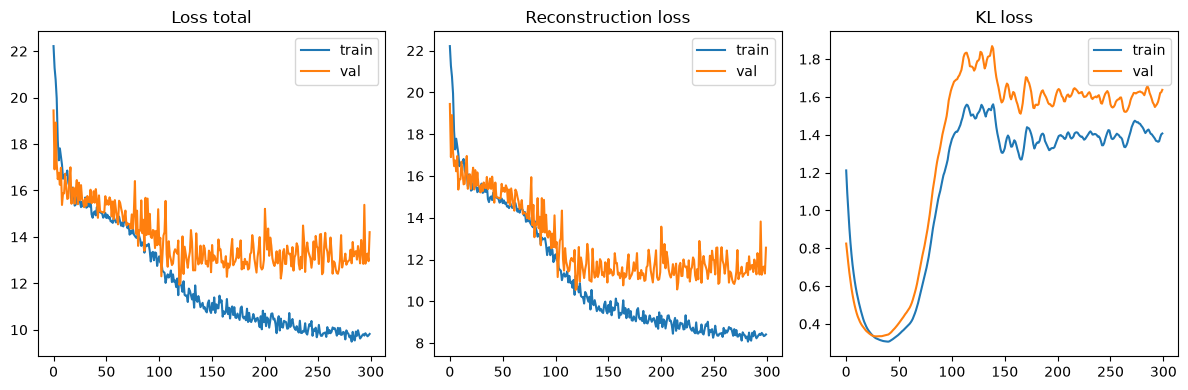

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss total")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history["recon_loss"], label="train")
plt.plot(history.history["val_recon_loss"], label="val")
plt.title("Reconstruction loss")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history["kl_loss"], label="train")
plt.plot(history.history["val_kl_loss"], label="val")
plt.title("KL loss")
plt.legend()

plt.tight_layout()
plt.show()

## Chequeo de reconstrucción

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


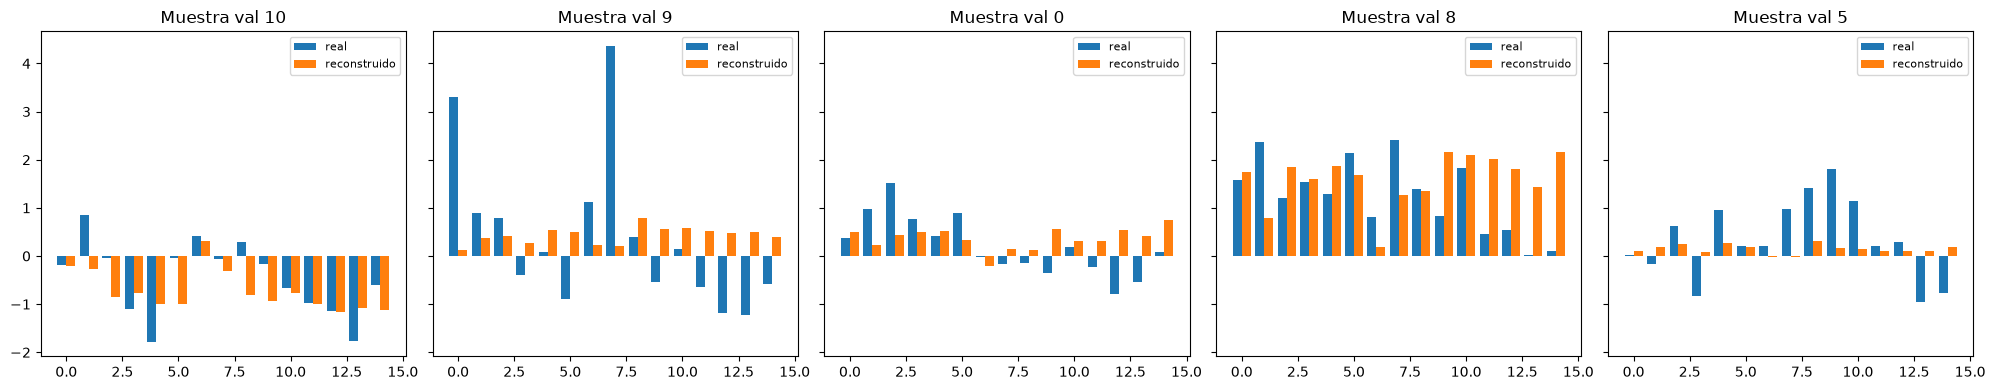

In [16]:
n_muestras = 5
idx_muestra = np.random.choice(len(X_val_s), n_muestras, replace=False)

z_mean_val, z_log_var_val, z_val = encoder.predict([X_val_s, y_val])
reconstruccion_val = decoder.predict([z_val, y_val])

fig, axes = plt.subplots(1, n_muestras, figsize=(4 * n_muestras, 4), sharey=True)
for ax, i in zip(axes, idx_muestra):
    ax.bar(np.arange(input_dim) - 0.2, X_val_s[i], width=0.4, label="real")
    ax.bar(np.arange(input_dim) + 0.2, reconstruccion_val[i], width=0.4, label="reconstruido")
    ax.set_title(f"Muestra val {i}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Espacio latente

Labels de validación: ['herbivory_caterpillar' 'herbivory_aphid' 'herbivory_caterpillar'
 'control' 'herbivory_caterpillar' 'infected_bacterial' 'infected_fungal'
 'infected_bacterial' 'infected_fungal' 'infected_bacterial' 'control'
 'herbivory_aphid']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


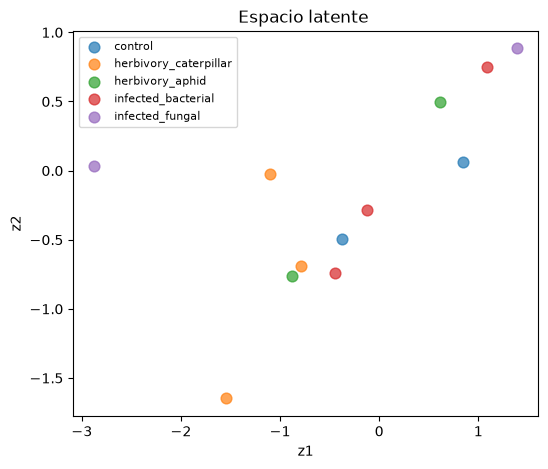

Silhouette score (validación): -0.29633137583732605


In [17]:
from sklearn.metrics import silhouette_score

def dummies_a_label(fila):
    if fila[0] == 1:
        return "herbivory_caterpillar"
    elif fila[1] == 1:
        return "herbivory_aphid"
    elif fila[2] == 1:
        return "infected_bacterial"
    elif fila[3] == 1:
        return "infected_fungal"
    else:
        return "control"

labels_val = np.array([dummies_a_label(fila) for fila in y_val])
print("Labels de validación:", labels_val)

z_mean_val, _, _ = encoder.predict([X_val_s, y_val])

plt.figure(figsize=(6, 5))
for lbl in ["control", "herbivory_caterpillar", "herbivory_aphid", "infected_bacterial", "infected_fungal"]:
    mask = labels_val == lbl
    plt.scatter(z_mean_val[mask, 0], z_mean_val[mask, 1], label=lbl, alpha=0.7, s=60)

plt.xlabel("z1")
plt.ylabel("z2")
plt.legend(fontsize=8)
plt.title("Espacio latente ")
plt.show()

sil = silhouette_score(z_mean_val, labels_val)
print("Silhouette score (validación):", sil)

## Exploraicón de gradiente

In [18]:
z_fixed = np.zeros((1, latent_dim))
n_steps = 11
c_steps = np.linspace(0, 1, n_steps).reshape(-1, 1)
z_repeated = np.repeat(z_fixed, n_steps, axis=0)

condiciones = ["herbivory_caterpillar", "herbivory_aphid", "infected_bacterial", "infected_fungal"]
resultados = {}

for i, cond_nombre in enumerate(condiciones):
    cond_vec = np.zeros((n_steps, 4))
    cond_vec[:, i] = c_steps.flatten()
    perfiles = decoder.predict([z_repeated, cond_vec])
    delta = perfiles[-1] - perfiles[0]

    cambios = pd.DataFrame({"compuesto_id": wide.columns, "delta": delta})
    cambios = cambios.merge(compuestos[["compuesto_id", "name_original", "pubchem_cid"]], on="compuesto_id", how="left")
    cambios = cambios.reindex(cambios["delta"].abs().sort_values(ascending=False).index)

    resultados[cond_nombre] = {"perfiles": perfiles, "cambios": cambios}

    print(f"\nTop compuestos — control -> {cond_nombre}:")
    display(cambios.head(5))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Top compuestos — control -> herbivory_caterpillar:


,compuesto_id,delta,name_original,pubchem_cid
8,moreira2024_cmp009,-0.130336,2-butyl-1-octanol,19800.0
1,moreira2024_cmp002,-0.118053,"5-Hepten-2-one, 6-methyl-",9862.0
6,moreira2024_cmp007,-0.110860,Nonanal,31289.0
14,moreira2024_cmp015,0.097205,a-farnesene,5281516.0
9,moreira2024_cmp010,0.051366,Tridecane,12388.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Top compuestos — control -> herbivory_aphid:


,compuesto_id,delta,name_original,pubchem_cid
8,moreira2024_cmp009,-0.357368,2-butyl-1-octanol,19800.0
9,moreira2024_cmp010,-0.286020,Tridecane,12388.0
6,moreira2024_cmp007,-0.182136,Nonanal,31289.0
1,moreira2024_cmp002,-0.147918,"5-Hepten-2-one, 6-methyl-",9862.0
11,moreira2024_cmp012,-0.110233,Farnesan,19773.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Top compuestos — control -> infected_bacterial:


,compuesto_id,delta,name_original,pubchem_cid
2,moreira2024_cmp003,0.436694,trans-a-bergamotene,6429302.0
0,moreira2024_cmp001,0.355528,Benzaldehyde,240.0
4,moreira2024_cmp005,0.350271,Limonene,22311.0
14,moreira2024_cmp015,0.297125,a-farnesene,5281516.0
10,moreira2024_cmp011,0.279035,Decanal,8175.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Top compuestos — control -> infected_fungal:


,compuesto_id,delta,name_original,pubchem_cid
8,moreira2024_cmp009,-0.376984,2-butyl-1-octanol,19800.0
1,moreira2024_cmp002,-0.333848,"5-Hepten-2-one, 6-methyl-",9862.0
6,moreira2024_cmp007,-0.314767,Nonanal,31289.0
14,moreira2024_cmp015,0.195519,a-farnesene,5281516.0
7,moreira2024_cmp008,0.136260,(E)-b-farnesene,10407.0


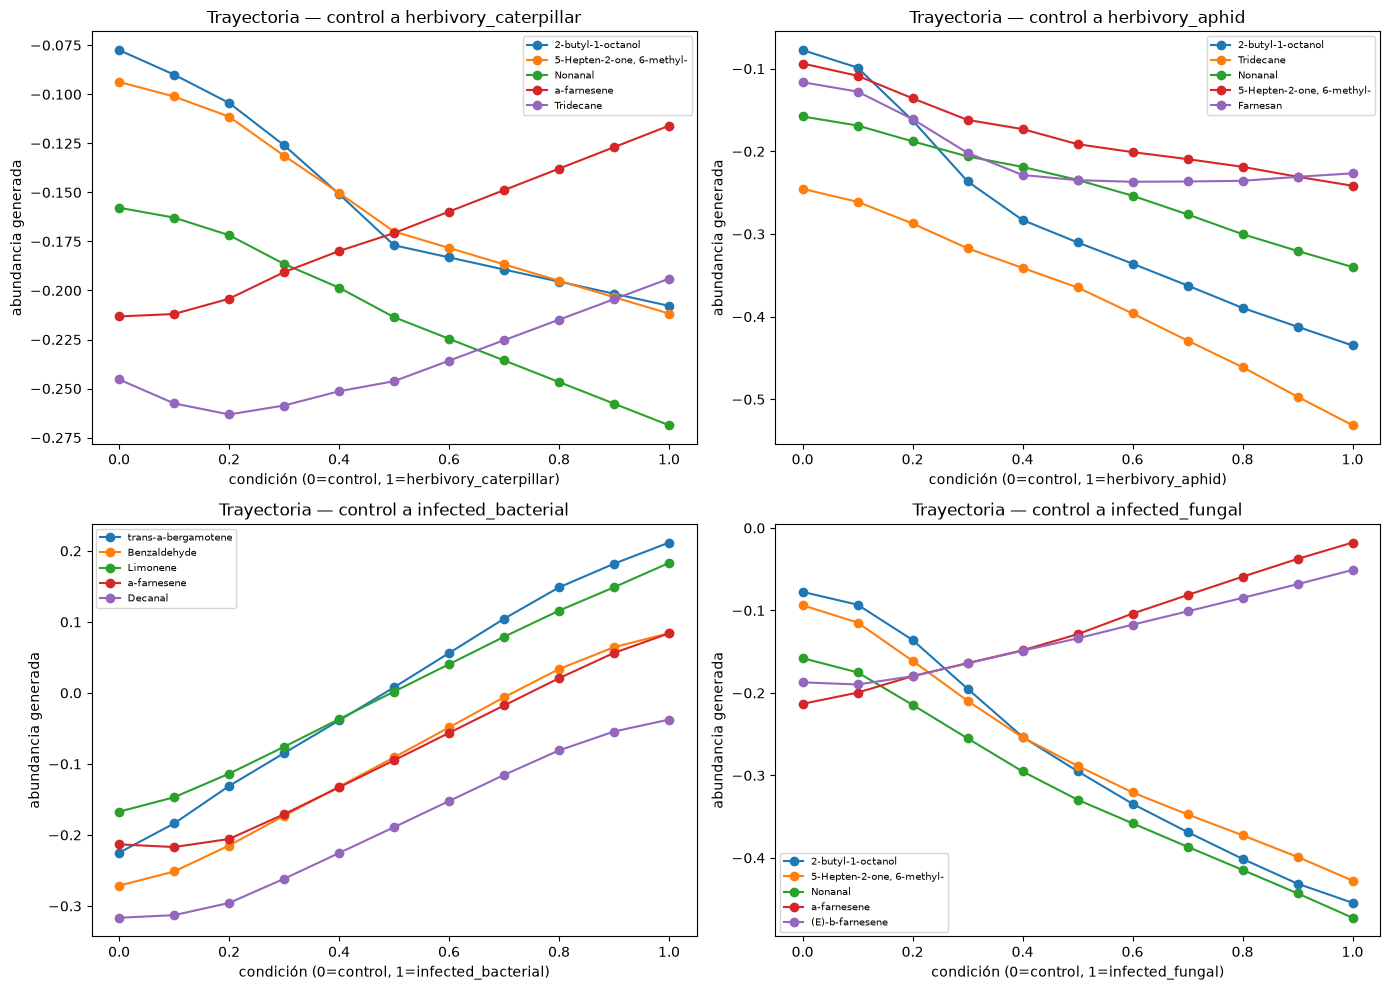

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, cond_nombre in zip(axes, condiciones):
    cambios = resultados[cond_nombre]["cambios"]
    perfiles = resultados[cond_nombre]["perfiles"]

    top5 = cambios.head(5)["compuesto_id"].tolist()
    idx_top5 = [list(wide.columns).index(cid) for cid in top5]

    for i, cid in zip(idx_top5, top5):
        nombre = compuestos.loc[compuestos["compuesto_id"] == cid, "name_original"].values
        etiqueta = nombre[0] if len(nombre) else cid
        ax.plot(c_steps.flatten(), perfiles[:, i], marker="o", label=etiqueta)

    ax.set_xlabel(f"condición (0=control, 1={cond_nombre})")
    ax.set_ylabel("abundancia generada")
    ax.legend(fontsize=7)
    ax.set_title(f"Trayectoria — control a {cond_nombre}")

plt.tight_layout()
plt.show()

# Etapa 4

In [20]:
#Isolation Forest
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import LeaveOneOut

X_real_moreira = np.vstack([X_train_s, X_val_s])
n_real_moreira = X_real_moreira.shape[0]
print(f"Muestras reales (colza): {n_real_moreira}")

iso_final_moreira = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
iso_final_moreira.fit(X_real_moreira)

loo = LeaveOneOut()
scores_loo_moreira = np.zeros(n_real_moreira)
for train_idx, test_idx in loo.split(X_real_moreira):
    iso_fold = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
    iso_fold.fit(X_real_moreira[train_idx])
    scores_loo_moreira[test_idx[0]] = -iso_fold.score_samples(X_real_moreira[test_idx])[0]

print("Distribución LOO IF:")
print(pd.Series(scores_loo_moreira).describe())

Muestras reales (colza): 60
Distribución LOO IF:
count    60.000000
mean      0.460005
std       0.038425
min       0.399386
25%       0.433359
50%       0.453463
75%       0.486450
max       0.558665
dtype: float64


In [21]:
# % de la distrib de referncia queda debajo de score 
def percentil_vs_referencia(score, referencia):
    return (referencia < score).mean() * 100

resultados_e4_moreira = {}
for cond_nombre, datos_e3 in resultados.items():
    perfiles = datos_e3["perfiles"]
    score_if = -iso_final_moreira.score_samples(perfiles)
    perc_if = np.array([percentil_vs_referencia(s, scores_loo_moreira) for s in score_if])
    resultados_e4_moreira[cond_nombre] = pd.DataFrame({
        "condicion": cond_nombre,
        "paso_condicion": c_steps.flatten(),
        "score_isolation_forest": score_if,
        "percentil_if_vs_reales": perc_if,
    })

for cond_nombre, df in resultados_e4_moreira.items():
    print(cond_nombre)
    print(df)
    print()

herbivory_caterpillar
                condicion  paso_condicion  score_isolation_forest  \
0   herbivory_caterpillar             0.0                0.379425   
1   herbivory_caterpillar             0.1                0.379048   
2   herbivory_caterpillar             0.2                0.379048   
3   herbivory_caterpillar             0.3                0.379600   
4   herbivory_caterpillar             0.4                0.380266   
5   herbivory_caterpillar             0.5                0.380266   
6   herbivory_caterpillar             0.6                0.380458   
7   herbivory_caterpillar             0.7                0.380458   
8   herbivory_caterpillar             0.8                0.380418   
9   herbivory_caterpillar             0.9                0.380056   
10  herbivory_caterpillar             1.0                0.380934   

    percentil_if_vs_reales  
0                      0.0  
1                      0.0  
2                      0.0  
3                      0.0  
4   

In [22]:
# Extrapolación para ver mas allá en una condición mayor a infected.
n_steps_extra = 11
c_steps_extra = np.linspace(1.0, 2.0, n_steps_extra).reshape(-1, 1)
z_repeated_extra = np.repeat(z_fixed, n_steps_extra, axis=0)

resultados_e4_moreira_extrap = {}
for i, cond_nombre in enumerate(condiciones):
    cond_vec_extra = np.zeros((n_steps_extra, 4))
    cond_vec_extra[:, i] = c_steps_extra.flatten()
    perfiles_extra = decoder.predict([z_repeated_extra, cond_vec_extra])
    score_if_extra = -iso_final_moreira.score_samples(perfiles_extra)
    perc_if_extra = np.array([percentil_vs_referencia(s, scores_loo_moreira) for s in score_if_extra])
    resultados_e4_moreira_extrap[cond_nombre] = pd.DataFrame({
        "condicion": cond_nombre,
        "paso_condicion": c_steps_extra.flatten(),
        "score_isolation_forest": score_if_extra,
        "percentil_if_vs_reales": perc_if_extra,
    })

for cond_nombre, df in resultados_e4_moreira_extrap.items():
    print(cond_nombre)
    print(df)
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
herbivory_caterpillar
                condicion  paso_condicion  score_isolation_forest  \
0   herbivory_caterpillar             1.0                0.380934   
1   herbivory_caterpillar             1.1                0.381000   
2   herbivory_caterpillar             1.2                0.380625   
3   herbivory_caterpillar             1.3                0.381057   
4   herbivory_caterpillar             1.4                0.381667   
5   herbivory_caterpillar             1.5                0.381987   
6   herbivory_caterpillar             1.6                0.381987   
7   herbivory_caterpillar             1.7                0.382025   
8   herbivory_caterpillar             1.8                0.382111   
9   herbivory_caterpillar             1.9                0.381892   
10  herbivory_caterpillar             2.0                0.383081  

In [23]:
# Detector no condicional, independiente del CVAE
def build_autoencoder(input_dim, bottleneck=4):
    inputs = tf.keras.Input(shape=(input_dim,))
    encoded = layers.Dense(16, activation="relu")(inputs)
    encoded = layers.Dense(8, activation="relu")(encoded)
    encoded = layers.Dense(bottleneck, activation="relu")(encoded)
    decoded = layers.Dense(8, activation="relu")(encoded)
    decoded = layers.Dense(16, activation="relu")(decoded)
    decoded = layers.Dense(input_dim, activation="linear")(decoded)
    ae = tf.keras.Model(inputs, decoded)
    ae.compile(optimizer="adam", loss="mse")
    return ae

def recon_error(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean((X - X_hat) ** 2, axis=1)

AE_EPOCHS = 150
AE_BATCH = 8

ae_final_moreira = build_autoencoder(X_real_moreira.shape[1])
ae_final_moreira.fit(X_real_moreira, X_real_moreira, epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)

loo = LeaveOneOut()
errores_loo_ae_moreira = np.zeros(n_real_moreira)
for train_idx, test_idx in loo.split(X_real_moreira):
    ae_fold = build_autoencoder(X_real_moreira.shape[1])
    ae_fold.fit(X_real_moreira[train_idx], X_real_moreira[train_idx], epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)
    errores_loo_ae_moreira[test_idx[0]] = recon_error(ae_fold, X_real_moreira[test_idx])[0]

print("Distribución LOO AE:")
print(pd.Series(errores_loo_ae_moreira).describe())

Distribución LOO AE:
count    60.000000
mean      0.527608
std       0.439634
min       0.040954
25%       0.274430
50%       0.384403
75%       0.657705
max       2.220471
dtype: float64


In [24]:
# Control + para validar
z_extremo_moreira = np.full((1, latent_dim), 5.0)
c_extremo_moreira = np.zeros((1, 4))
c_extremo_moreira[0, 0] = 1.0

perfil_control_positivo_moreira = decoder.predict([z_extremo_moreira, c_extremo_moreira])

score_if_control_moreira = -iso_final_moreira.score_samples(perfil_control_positivo_moreira)[0]
error_ae_control_moreira = recon_error(ae_final_moreira, perfil_control_positivo_moreira)[0]

print(f"  Score Isolation Forest: {score_if_control_moreira:.4f}  (percentil {percentil_vs_referencia(score_if_control_moreira, scores_loo_moreira):.1f}%)")
print(f"  Error autoencoder:      {error_ae_control_moreira:.4f}  (percentil {percentil_vs_referencia(error_ae_control_moreira, errores_loo_ae_moreira):.1f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
  Score Isolation Forest: 0.6216  (percentil 100.0%)
  Error autoencoder:      0.1945  (percentil 13.3%)


In [25]:
#Clasicicaión final
for i, cond_nombre in enumerate(condiciones):
    # Interpolado
    perfiles = resultados[cond_nombre]["perfiles"]
    error_ae = recon_error(ae_final_moreira, perfiles)
    resultados_e4_moreira[cond_nombre]["percentil_ae_vs_reales"] = [
        percentil_vs_referencia(e, errores_loo_ae_moreira) for e in error_ae
    ]

    # Extrapolado
    cond_vec_extra = np.zeros((n_steps_extra, 4))
    cond_vec_extra[:, i] = c_steps_extra.flatten()
    perfiles_extra = decoder.predict([z_repeated_extra, cond_vec_extra])
    error_ae_extra = recon_error(ae_final_moreira, perfiles_extra)
    resultados_e4_moreira_extrap[cond_nombre]["percentil_ae_vs_reales"] = [
        percentil_vs_referencia(e, errores_loo_ae_moreira) for e in error_ae_extra
    ]

def clasificar(perc_if, perc_ae=None):
    percentiles = [p for p in [perc_if, perc_ae] if p is not None]
    if all(p > 97.5 for p in percentiles):
        return "novedoso"
    elif all(p < 90 for p in percentiles):
        return "plausible"
    else:
        return "frontera"

for cond_nombre in condiciones:
    resultados_e4_moreira[cond_nombre]["clasificacion"] = [
        clasificar(row.percentil_if_vs_reales, row.percentil_ae_vs_reales)
        for row in resultados_e4_moreira[cond_nombre].itertuples()
    ]
    resultados_e4_moreira_extrap[cond_nombre]["clasificacion"] = [
        clasificar(row.percentil_if_vs_reales, row.percentil_ae_vs_reales)
        for row in resultados_e4_moreira_extrap[cond_nombre].itertuples()
    ]

for cond_nombre in condiciones:
    print(f"=== {cond_nombre} — interpolado ===")
    print(resultados_e4_moreira[cond_nombre][["paso_condicion", "clasificacion"]])
    print(f"=== {cond_nombre} — extrapolado ===")
    print(resultados_e4_moreira_extrap[cond_nombre][["paso_condicion", "clasificacion"]])
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
=== herbivory_caterpillar — interpolado ===
    paso_condicion clasificacion
0              0.0     plausible
1              0.1     plausible
2              0.2     plausible
3              0.3     plausible
4              0.4     plausible
5              0.5     plausible
6              0.6     plausible
7              0.7     plausible
8              0.8     plausible
9              0.9     plausible
10             1.0     plausible
=== herbivory_caterpillar — extrapolado ===
    paso_condicion clasificacion
0              1.0     plausible
1              1.1     plausible
2              1.2     plausible
3              1.3     plausible
4              1.4     plausible
5              1.5     plausible
6              1.6     plausible
7              1.7     plausible
8              1.8     plausible
9              1.9     plausible
1

In [26]:
#Resúemn 
def resumen_especie(nombre_especie, detectores_usados, *tablas_clasificadas):
    todas = pd.concat(tablas_clasificadas, ignore_index=True)
    n = len(todas)
    conteo = todas["clasificacion"].value_counts(normalize=True).mul(100).round(1)
    return {
        "especie": nombre_especie,
        "detectores": detectores_usados,
        "n_perfiles_evaluados": n,
        "% plausible": conteo.get("plausible", 0.0),
        "% frontera": conteo.get("frontera", 0.0),
        "% novedoso": conteo.get("novedoso", 0.0),
    }

tablas_colza = list(resultados_e4_moreira.values()) + list(resultados_e4_moreira_extrap.values())
fila_colza = resumen_especie("Moreira 2024", "IF + AE", *tablas_colza)
print(fila_colza)

import os
RESUMEN_PATH = "../resumen_e4.csv" 
fila_df = pd.DataFrame([fila_colza])
if os.path.exists(RESUMEN_PATH):
    fila_df.to_csv(RESUMEN_PATH, mode="a", header=False, index=False)
else:
    fila_df.to_csv(RESUMEN_PATH, mode="w", header=True, index=False)

pd.read_csv(RESUMEN_PATH)

{'especie': 'Moreira 2024', 'detectores': 'IF + AE', 'n_perfiles_evaluados': 88, '% plausible': np.float64(100.0), '% frontera': 0.0, '% novedoso': 0.0}


,especie,detectores,n_perfiles_evaluados,% plausible,% frontera,% novedoso
0,Colza (Moreira 2024),IF + AE,88,100.0,0.0,0.0
1,Algodón (Ayelo 2026),IF + AE,22,95.5,4.5,0.0
2,Moreira 2024,IF + AE,88,100.0,0.0,0.0


In [28]:
export_cvae(
    "moreira2024",
    encoder=encoder, decoder=decoder, iso_forest=iso_final_moreira, autoencoder=ae_final_moreira,
    scores_loo=scores_loo_moreira, errores_loo_ae=errores_loo_ae_moreira, scaler=scaler, compound_ids=wide.columns,
    meta={"especie": "Brassica rapa (Moreira 2024)"}
)

Exportado CVAE+detectores: moreira2024 -> ..\models\moreira2024
